<a href="https://colab.research.google.com/github/Akshaya-Biju/ML-lab/blob/main/exp_3_Ridge_Lasso_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score


In [37]:
diabetes = load_diabetes()

x = diabetes.data
y = diabetes.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [38]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])

Training samples: 353
Testing samples: 89


In [39]:
linear_model = LinearRegression()
linear_model.fit(x_train_scaled,y_train)

y_pred_linear = linear_model.predict(x_test_scaled)

print("Linear Regression:")
print("Mean Squared Error:",mean_squared_error(y_test,y_pred_linear))
print("R2 Score:",r2_score(y_test,y_pred_linear))


Linear Regression:
Mean Squared Error: 2900.1936284934823
R2 Score: 0.45260276297191926


In [40]:
ridge = Ridge()
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge_cv = GridSearchCV(ridge, param_grid, cv=5)
ridge_cv.fit(x_train_scaled, y_train)

best_ridge = ridge_cv.best_estimator_

y_pred_ridge = best_ridge.predict(x_test_scaled)

print("Best Alpha for Ridge:",ridge_cv.best_params_['alpha'])
print("MSE:",mean_squared_error(y_test,y_pred_ridge))
print("R-squared:",r2_score(y_test,y_pred_ridge))



Best Alpha for Ridge: 10
MSE: 2875.7787184218428
R-squared: 0.4572109567780849


In [41]:
lasso = Lasso(max_iter=10000)

lasso_cv = GridSearchCV(lasso, param_grid, cv=5)
lasso_cv.fit(x_train_scaled, y_train)

best_lasso = lasso_cv.best_estimator_

y_pred_lasso = best_lasso.predict(x_test_scaled)

print("Best Alpha for Lasso:",lasso_cv.best_params_['alpha'])
print("MSE =",mean_squared_error(y_test,y_pred_lasso))
print("R-squared =",r2_score(y_test,y_pred_lasso))

Best Alpha for Lasso: 1
MSE = 2824.568094049959
R-squared = 0.46687670944102466


In [42]:
result = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MSE': [mean_squared_error(y_test, y_pred_linear),
            mean_squared_error(y_test, y_pred_ridge),
            mean_squared_error(y_test,y_pred_lasso)],
     'R2 score': [r2_score(y_test, y_pred_linear),
                  r2_score(y_test, y_pred_ridge),
                  r2_score(y_test,y_pred_lasso)]
})
print(result)

               Model          MSE  R2 score
0  Linear Regression  2900.193628  0.452603
1   Ridge Regression  2875.778718  0.457211
2   Lasso Regression  2824.568094  0.466877


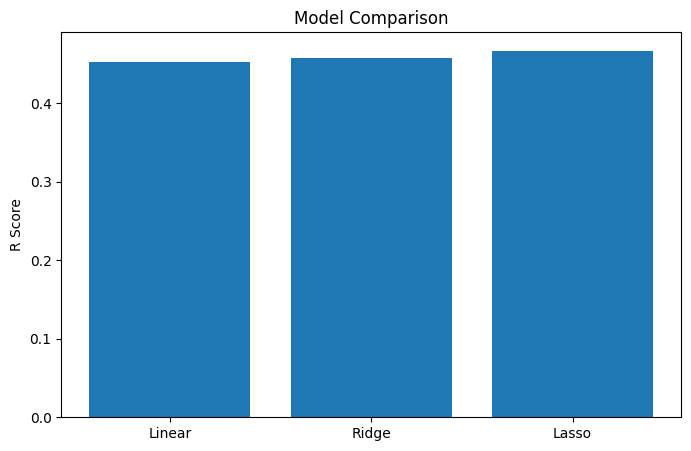

In [43]:
plt.figure(figsize=(8,5))

models = ['Linear', 'Ridge', 'Lasso']
r2_scores = [r2_score(y_test, y_pred_linear),
             r2_score(y_test, y_pred_ridge),
             r2_score(y_test, y_pred_lasso)]

plt.bar(models, r2_scores)
plt.ylabel('R Score')
plt.title('Model Comparison')
plt.show()

